# Lecture 04  
### Python Performance Tuning   
### February 11, 2026


### Diagnosing and solving performance issues with profiling

https://nyu-cds.github.io/python-performance-tuning/

Install line_profiler: `conda install line_profiler`

- Python interpreter implementations, such as CPython, attempt to optimize the performance of the running program.
  
- However the nature of the Python language can make this a challenging task.

  
- Dynamic types and other Python features prevent the language from being statically optimized, so there are many tasks that can only be performed when the program runs.

- In addition, Python data types can be inefficient if used incorrectly, so it is important to ensure that the right data structure is used for the job.

- In order to optimize a program, it is essential to understand where the bottlenecks are.
  
- These are the places where the program is spending most of its time. 


### What is profiling?

* A *profile* is a set of statistics describing how often and for how long various parts of a program run
* Useful for identifying performance bottlenecks that could be optimized
* Profiling can induce a performance overhead (but relatively small in Python)

### _Deterministic_ vs _Statistical_

- _Deterministic_ profiling is meant to reflect the fact that all function call, function return, and exception events are monitored, and precise timings are made for the intervals between these events (during which time the user’s code is executing).

- Deterministic profiles are obtined by instrumenting the program - inserting intructions into the program that collect this timing information.


- _Statistical_ profiling is a process that randomly samples the effective instruction pointer, and deduces where time is being spent.

- This technique traditionally involves less overhead as the code does not need to be instrumented, but provides only relative indications of where time is being spent.

In Python, there is an interpreter active during execution, so the presence of instrumented code is not required to do deterministic profiling. 

Python automatically provides a hook (optional callback) for each event. 

In addition, the interpreted nature of Python tends to add so much overhead to execution, that deterministic profiling only adds small processing overhead in typical applications.

The result is that deterministic profiling is not expensive, yet provides extensive run time statistics about the execution of a Python program.

- Call counts (i.e. how many times a function is called) and profiling statistics can be used for a variety of purposes:

Unusual count numbers can help identify bugs in code.

High call counts can help to identify possible points where in-lining (unwrapping loops) might benefit.

Internal time statistics can be used to identify “hot loops” that should be carefully optimized.

Cumulative time statistics can be used to identify high level errors in the selection of algorithms.

  

## Profiling in Python

Python has two standard modules that provide the same profiling interface: cProfile and profile. 

The cProfile module has the lowest overhead, but because it is written in C, may not be as widely available.

The profile module is written in Python, so has a much higher overhead, but is easier to extend. 

There is also a newer module, called line_profiler that profiles on a line-by-line basis. This module is not part of the standard distribution, so needs to be installed separately.


### cProfile vs line_profile

**cProfile**: measures number of function calls and their execution time (in the function itself, including sub-calls or not)

**line_profiler**: measures number of executions and time for individual lines/statements (useful when individual statements could be slow, e.g., with Numpy)

### Monte Carlo Simultations for $\pi$ 

Suppose we want to approximate $\pi$ by using the following Monte Carlo simulations based on the geometric probability:

--- 

Plot the $1/4$-of the unit circle: $(x, \sqrt{1 - x^2})$ over the segment $[0, 1]$.

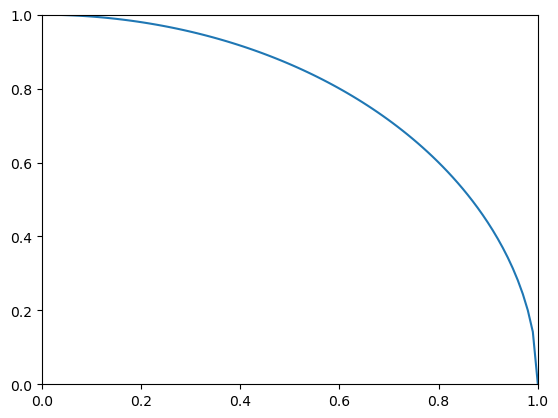

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# plot a quarter of the unit circle
x = np.linspace(0, 1.0, 100)
plt.plot(x, (1 - x ** 2) ** 0.5)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

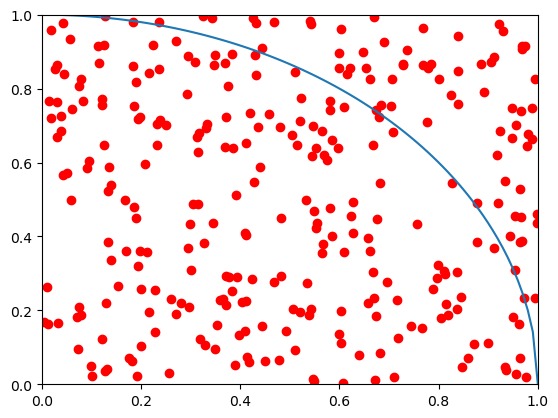

In [2]:
#plot random points

number_of_points = 300
plt.plot(np.random.random(number_of_points), np.random.random(number_of_points), 'ro')

# plot a quarter of the unit circle
x = np.linspace(0, 1.0, 100)
plt.plot(x, np.sqrt(1 - x ** 2))

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()

### Prob(a ranodm point belongs to the 1/4-unit-circle) = Area(1/4-unit-circle)/Area(unit-square) = Pi/4

In [3]:
import random

def inside_quarter_circle(x, y):
    """indicator that (x,y) belongs to the quarter of the circle"""
    return int(x ** 2 + y ** 2 <= 1.0)

def approx_pi_mc(number_of_points):
    """monte-carlo PI"""

    counter = 0

    for i in range(number_of_points):
        x = random.random()
        y = random.random()
        counter += inside_quarter_circle(x, y)

    pi_approx = 4 * counter / number_of_points
    print("pi_approx:", pi_approx)
    return pi_approx

In [4]:
%timeit -n 1 -r 1 approx_pi_mc(1_000_000)

pi_approx: 3.14076
213 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


Python provides a C module called cProfile, and using it is quite simple.

All you need to do is import the module and call its run function.

In [5]:
# cProfile and profile provide deterministic profiling
import cProfile
cProfile.run('approx_pi_mc(1_000_000)')

pi_approx: 3.143208
         3000058 function calls in 0.387 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
  1000000    0.126    0.000    0.126    0.000 2661370469.py:3(inside_quarter_circle)
        1    0.208    0.208    0.387    0.387 2661370469.py:7(approx_pi_mc)
        1    0.000    0.000    0.387    0.387 <string>:1(<module>)
        1    0.000    0.000    0.000    0.000 iostream.py:138(_event_pipe)
        1    0.000    0.000    0.000    0.000 iostream.py:259(schedule)
        4    0.000    0.000    0.000    0.000 iostream.py:505(parent_header)
        4    0.000    0.000    0.000    0.000 iostream.py:550(_is_master_process)
        4    0.000    0.000    0.000    0.000 iostream.py:577(_schedule_flush)
        4    0.000    0.000    0.000    0.000 iostream.py:655(write)
        1    0.000    0.000    0.000    0.000 socket.py:623(send)
        1    0.000    0.000    0.000    0.000 threading.py:1102(_wait_for_tstate

The first line indicates the number of calls that were monitored. 

Of those calls, some were primitive, meaning that the call was not induced via recursion.

The next line, “Ordered by: standard name”, indicates that the text string in the last column was used to sort the output. 

The column headings (from left to right) are:

- _ncalls_ - for the number of calls
- _tottime_- for the total time spent in the given function (and excluding time made in calls to sub-functions)
- _percall_ - is the quotient of tottime divided by ncalls
- _cumtime_ - is the cumulative time spent in this and all subfunctions (from invocation till exit). This figure is accurate even for recursive functions
- _percall_ - is the quotient of cumtime divided by primitive calls
- filename: _lineno(function)_ - provides the respective data of each function

When there are two numbers in the first column (for example 3/1), it means that the function recursed.

The second value is the number of primitive calls and the former is the total number of calls.

Note that when the function does not recurse, these two values are the same, and only the single figure is printed.

- From IPython, the same result can be achieved by using the %prun magic command or %%prun cell magic command.

In [6]:
# run a code with the profiler

#%prun is a specific magic command to evaluate how much time your function or program to execute each function.

%prun approx_pi_mc(1_000_000)

pi_approx: 3.142104
 

         3000058 function calls in 0.391 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.209    0.209    0.391    0.391 2661370469.py:7(approx_pi_mc)
  1000000    0.130    0.000    0.130    0.000 2661370469.py:3(inside_quarter_circle)
  2000000    0.053    0.000    0.053    0.000 {method 'random' of '_random.Random' objects}
        1    0.000    0.000    0.000    0.000 socket.py:623(send)
        4    0.000    0.000    0.000    0.000 iostream.py:655(write)
        1    0.000    0.000    0.391    0.391 {built-in method builtins.exec}
        1    0.000    0.000    0.000    0.000 {built-in method builtins.print}
        1    0.000    0.000    0.000    0.000 iostream.py:259(schedule)
        4    0.000    0.000    0.000    0.000 iostream.py:505(parent_header)
        4    0.000    0.000    0.000    0.000 iostream.py:577(_schedule_flush)
        4    0.000    0.000    0.000    0.000 iostream.py:550(_is_master_pr

- The cProfile module shows how much time is being spent in each function.
-  This is a good first step for locating hotspots in a program, and is frequently all that is needed to optimize the code.
-  However, sometimes the cause of the hotspot is actually a single line in the function, and that line may not be obvious from just reading the source code.

These cases are particularly frequent in scientific computing. 

Functions tend to be larger (sometimes because of legitimate algorithmic complexity, sometimes because the programmer is still trying to write FORTRAN code), and a single statement without function calls can trigger lots of computation when using libraries like NumPy. (e.g. `y = np.linalg.inv(X) @ b`)



### line_profiler
Sometimes the cause of the hotspot is a single line in a function, which may not be obvious from reading the source code or analyzing the output of cProfile.

The __line_profiler__ times the execution of each individual line inside a function. 

- The line_profiler can be given functions to profile, and it will time the execution of each individual line inside those functions.
- In a typical workflow, it is only useful to examine the line timings of a few functions because wading through the results of timing every single line of code would be overwhelming.




The __line_profiler__ can be used by loading in Jupyer as:

In [7]:
# pip install line-profiler

In [8]:
%load_ext line_profiler

Once you have loaded this function, you can profile it with the line profiler using the following command. 

The “-f” option tells %lprun which function to profile.

In [9]:
# run code with the line-by-line profiler
%lprun -f approx_pi_mc approx_pi_mc(1_000_000)

# -f : tells which function to profile

pi_approx: 3.140764


Timer unit: 1e-09 s

Total time: 1.11408 s
File: /var/folders/vj/mhdkxj391ljd_nk06v7m8hm40000gn/T/ipykernel_30117/2661370469.py
Function: approx_pi_mc at line 7

Line #      Hits         Time  Per Hit   % Time  Line Contents
     7                                           def approx_pi_mc(number_of_points):
     8                                               """monte-carlo PI"""
     9                                           
    10         1          0.0      0.0      0.0      counter = 0
    11                                           
    12   1000001  189677000.0    189.7     17.0      for i in range(number_of_points):
    13   1000000  183076000.0    183.1     16.4          x = random.random()
    14   1000000  179196000.0    179.2     16.1          y = random.random()
    15   1000000  561945000.0    561.9     50.4          counter += inside_quarter_circle(x, y)
    16                                           
    17         1       9000.0   9000.0      0.0      pi_approx =

The line profiler will display some information about the execution, including the line “Timer unit:” which gives the conversion factor to seconds for time information. 

It then shows a table with the following column headings (from left to right):

- _Line_ # - The line number in the code
- _Hits_ - The number of times that line was executed
- _Time_ - The total amount of time spent executing the line in the timer’s units
- _Per Hit_ - The average amount of time spent executing the line once in the timer’s unit
- _% Time_ - The percentage of time spent on that line relative to the total amount of recorded time spent in the function
- _Line Contents_ - The actual source code of the line

From the output, you can see that most of the time was spent at each lines, and also at line 15: `counter += inside_quarter_circle(x, y)`.

If we are to improve the performance of this function, then we should focus on these lines.

In [10]:
def approx_pi_mc_faster(total_number):

    # generate a vector of random points
    random_vect = np.random.rand(total_number, 2)

    # check if points belong to the circle
    bool_inside = random_vect[:, 0] ** 2 + random_vect[:, 1] ** 2 <= 1

    # count those
    # counter = sum(bool_inside)
    counter = np.sum(bool_inside, dtype=np.int32)

    pi_approx = 4 * counter / total_number
    print("pi_approx:", pi_approx)
    return pi_approx

In [11]:
# %prun approx_pi_mc_faster(1_000_000)

%lprun -f approx_pi_mc_faster approx_pi_mc_faster(1_000_000)


pi_approx: 3.14172


Timer unit: 1e-09 s

Total time: 0.01452 s
File: /var/folders/vj/mhdkxj391ljd_nk06v7m8hm40000gn/T/ipykernel_30117/32560212.py
Function: approx_pi_mc_faster at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def approx_pi_mc_faster(total_number):
     2                                           
     3                                               # generate a vector of random points
     4         1    8513000.0 8.51e+06     58.6      random_vect = np.random.rand(total_number, 2)
     5                                           
     6                                               # check if points belong to the circle
     7         1    4170000.0 4.17e+06     28.7      bool_inside = random_vect[:, 0] ** 2 + random_vect[:, 1] ** 2 <= 1
     8                                           
     9                                               # count those
    10                                               # counter =

## Performance Tuning -- Line Profiling  

#### Example: Heat Equation

#### How does the heat transfer?   

#### Finite Element Methods


Note: below math formulas are not important for this example notebook. If interested, you can take a look at it. The main idea is that we are simulating heat transfer on a 2D grid. A point's temperature updates based on **the average of its 4 neighbors** (Finite Element Method). 

Consider a function (concretely temperature) $f = f(x, y, t)$ which depends on $(x,y) \in [0,1] \times [0,1]$ and time $t \geq 0$. 

Temperature satisfies the __heat equation__ (https://en.wikipedia.org/wiki/Heat_equation):
$$
\frac{\partial f}{\partial t} = \alpha^2 \left(\frac{\partial^2 f}{ \partial x^2} + \frac{\partial^2 f}{ \partial y^2} \right) \,.
$$

The rate at which the temperature changes $\frac{\partial f}{\partial t}$ is proportional to the 
Laplacian of the temperature function $\left(\frac{\partial^2 f}{ \partial x^2} + \frac{\partial^2 f}{ \partial y^2} \right)$.

In steady state $\partial f/\partial t = 0$, so (the __Poisson equation__):
$$
\frac{\partial^2 f}{\partial x^2}+\frac{\partial^2 f}{\partial y^2}=0.
$$

By using central difference in a square $[0,1]\times[0,1]$ regular grid:
$$
\frac{\partial^2 f}{\partial x^2}\approx\frac{f_{i+1,j}-2f_{i,j}+f_{i-1,j}}{\Delta x^2}\,,
$$

$$
\frac{\partial^2 f}{\partial y^2}\approx\frac{f_{i,j+1}-2f_{i,j}+f_{i,j-1}}{\Delta y^2}\,.
$$

We will assume $\Delta x = \Delta y$, so it follows:
$$
f_{i,j} = \frac{f_{i+1,j}+f_{i-1,j} + f_{i,j+1} + f_{i,j-1}}{4} \,.
$$

We will also assume that $f$ is known on the boundary of the square domain.

In [42]:
from itertools import product
import numpy as np

def build_grid(n):
    '''defines the grid'''
    G = np.zeros((n, n))
    return G

def set_boundary_grid(G):
    '''set the boundary values'''
    G[:, 0]  = 1
    G[0, :]  = 1
    G[-1, :] = 1
    G[:, -1] = 1


In [40]:
import matplotlib.pyplot as plt

def plot_grid(G):
    img = plt.imshow(G)
    img.set_cmap('rainbow')
    plt.axis('off')
    plt.show()


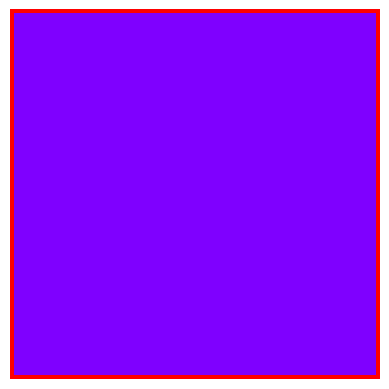

In [41]:
size_of_grid = 100

G = build_grid(n=size_of_grid)
set_boundary_grid(G)
plot_grid(G)

In [16]:
# using two-loops
def iteration_loops(G):
    n = G.shape[0]
    for i in range(1, n-1):
        for j in range(1, n-1):
            # calculate the average
            G[i, j] = (G[i + 1, j] + G[i - 1, j] + G[i, j + 1] + G[i, j - 1]) / 4


# using iterators to traverse the grid
def iteration_gen(G):
    n = G.shape[0]
    indices = product(range(1, n-1), repeat=2)
    for e in indices:
        G[e]=(G[e[0] + 1, e[1]] + G[e[0] - 1, e[1]] + G[e[0], e[1] + 1] + G[e[0], e[1] - 1])/4


In [17]:
# auxiliary functions:

# calculate error between G1 and G2
def calc_error(G1, G2):
    error = 0
    n = G1.shape[0]
    for i in range(n):
        for j in range(n):
            error += (G1[i, j] - G2[i, j]) ** 2
    # normalize the error
    return error / n**2


# using numpy built-in functions to compute the error
def calc_error_np(G1, G2):
    error = np.square(np.subtract(G1, G2)).mean()
    return error


# deep copy of G1 to G2
def copy_array(G1, G2):
    G2[:, :] = G1[:, :]


In [18]:
def solve_heat_equation1(n):
    G = build_grid(n)
    set_boundary_grid(G)

    G_prev = build_grid(n)
    copy_array(G, G_prev)

    error = float("inf")
    while error > 1e-7:
        iteration_loops(G)
        error = calc_error(G, G_prev)
        copy_array(G, G_prev)
    return G

In [19]:
%lprun -f solve_heat_equation1 G1 = solve_heat_equation1(size_of_grid)

Timer unit: 1e-09 s

Total time: 10.6741 s
File: /var/folders/vj/mhdkxj391ljd_nk06v7m8hm40000gn/T/ipykernel_30117/1740510040.py
Function: solve_heat_equation1 at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def solve_heat_equation1(n):
     2         1      90000.0  90000.0      0.0      G = build_grid(n)
     3         1      29000.0  29000.0      0.0      set_boundary_grid(G)
     4                                           
     5         1      53000.0  53000.0      0.0      G_prev = build_grid(n)
     6         1      18000.0  18000.0      0.0      copy_array(G, G_prev)
     7                                           
     8         1       2000.0   2000.0      0.0      error = float("inf")
     9       935     676000.0    723.0      0.0      while error > 1e-7:
    10       934 6633248000.0  7.1e+06     62.1          iteration_loops(G)
    11       934 4032610000.0 4.32e+06     37.8          error = calc_

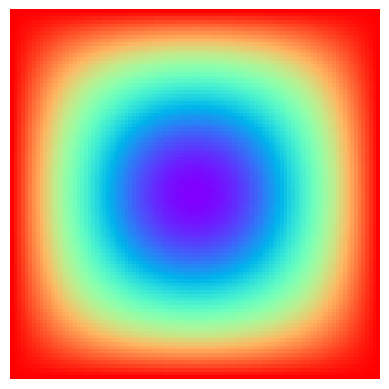

In [20]:
plot_grid(G1)

In [21]:
def solve_heat_equation2(n):
    '''changing to calc_error_np function'''
    G = build_grid(n)
    set_boundary_grid(G)

    G_prev = build_grid(n)
    copy_array(G, G_prev)

    error = np.float64("inf")
    while error > 1e-7:
        iteration_loops(G)
        error = calc_error_np(G,G_prev)
        copy_array(G,G_prev)

    return G

In [22]:
%lprun -f solve_heat_equation2 G2 = solve_heat_equation2(size_of_grid)

Timer unit: 1e-09 s

Total time: 6.67573 s
File: /var/folders/vj/mhdkxj391ljd_nk06v7m8hm40000gn/T/ipykernel_30117/4037319599.py
Function: solve_heat_equation2 at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def solve_heat_equation2(n):
     2                                               '''changing to calc_error_np function'''
     3         1     150000.0 150000.0      0.0      G = build_grid(n)
     4         1      37000.0  37000.0      0.0      set_boundary_grid(G)
     5                                           
     6         1       8000.0   8000.0      0.0      G_prev = build_grid(n)
     7         1       9000.0   9000.0      0.0      copy_array(G, G_prev)
     8                                           
     9         1       3000.0   3000.0      0.0      error = np.float64("inf")
    10       935     420000.0    449.2      0.0      while error > 1e-7:
    11       934 6624568000.0 7.09e+06     99.2

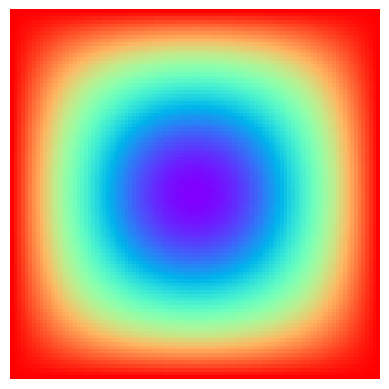

In [23]:
plot_grid(G2)

In [24]:
def solve_heat_equation3(n):
    '''changing to iteration_gen function'''
    G = build_grid(n)
    set_boundary_grid(G)

    G_prev = build_grid(n)
    copy_array(G, G_prev)

    error = float("inf")
    while error > 1e-7:
        iteration_gen(G)
        error = calc_error(G,G_prev)
        copy_array(G, G_prev)

    return(G)

In [25]:
%lprun -f solve_heat_equation3 G3 = solve_heat_equation3(size_of_grid)

Timer unit: 1e-09 s

Total time: 12.0112 s
File: /var/folders/vj/mhdkxj391ljd_nk06v7m8hm40000gn/T/ipykernel_30117/3237369717.py
Function: solve_heat_equation3 at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def solve_heat_equation3(n):
     2                                               '''changing to iteration_gen function'''
     3         1      20000.0  20000.0      0.0      G = build_grid(n)
     4         1      29000.0  29000.0      0.0      set_boundary_grid(G)
     5                                           
     6         1     117000.0 117000.0      0.0      G_prev = build_grid(n)
     7         1      18000.0  18000.0      0.0      copy_array(G, G_prev)
     8                                           
     9         1       3000.0   3000.0      0.0      error = float("inf")
    10       935     669000.0    715.5      0.0      while error > 1e-7:
    11       934 8016298000.0 8.58e+06     66.7     

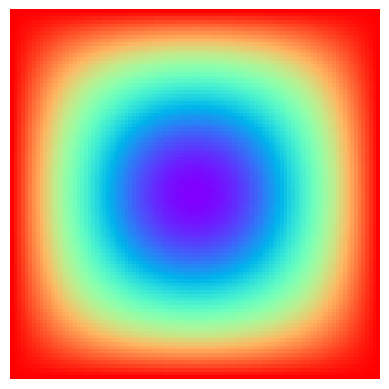

In [26]:
plot_grid(G3)

In [27]:
def solve_heat_equation4(n):
    '''changing to both calc_error_np and iteration_gen functions'''
    G = build_grid(n)
    set_boundary_grid(G)

    G_prev = build_grid(n)
    copy_array(G, G_prev)

    error = float("inf")
    while error > 1e-7:
        iteration_gen(G)
        error = calc_error_np(G, G_prev)
        copy_array(G, G_prev)
    return G

In [28]:
%lprun -f solve_heat_equation4 G4 = solve_heat_equation4(size_of_grid)

Timer unit: 1e-09 s

Total time: 8.01035 s
File: /var/folders/vj/mhdkxj391ljd_nk06v7m8hm40000gn/T/ipykernel_30117/2157240811.py
Function: solve_heat_equation4 at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def solve_heat_equation4(n):
     2                                               '''changing to both calc_error_np and iteration_gen functions'''
     3         1      12000.0  12000.0      0.0      G = build_grid(n)
     4         1      25000.0  25000.0      0.0      set_boundary_grid(G)
     5                                           
     6         1       5000.0   5000.0      0.0      G_prev = build_grid(n)
     7         1      10000.0  10000.0      0.0      copy_array(G, G_prev)
     8                                           
     9         1       1000.0   1000.0      0.0      error = float("inf")
    10       935     471000.0    503.7      0.0      while error > 1e-7:
    11       934 7956005000.

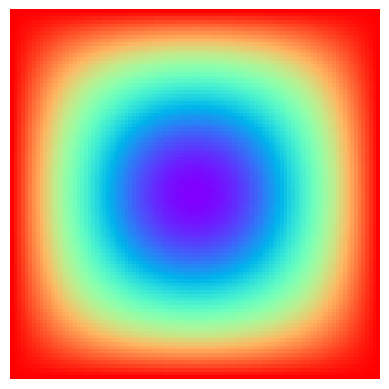

In [29]:
plot_grid(G4)

In [30]:
# different update (synchronous instead of asynchronous) but using only numpy
def iteration_np(G):
    n = G.shape[0]
    G[1:n-1,1:n-1] = (G[:n-2,1:n-1] + G[2:,1:n-1] + G[1:n-1,:n-2] + G[1:n-1,2:]) / 4

In [31]:
def solve_heat_equation5(n):
    '''all using numpy'''
    G = build_grid(n)
    set_boundary_grid(G)

    G_prev = build_grid(n)
    copy_array(G, G_prev)

    error = np.inf
    while error > 1e-7:
        iteration_np(G)
        error = calc_error_np(G, G_prev)
        copy_array(G, G_prev)
    return G

In [32]:
%lprun -f solve_heat_equation5 G5 = solve_heat_equation5(size_of_grid)

Timer unit: 1e-09 s

Total time: 0.037109 s
File: /var/folders/vj/mhdkxj391ljd_nk06v7m8hm40000gn/T/ipykernel_30117/4256048247.py
Function: solve_heat_equation5 at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def solve_heat_equation5(n):
     2                                               '''all using numpy'''
     3         1     217000.0 217000.0      0.6      G = build_grid(n)
     4         1      33000.0  33000.0      0.1      set_boundary_grid(G)
     5                                           
     6         1      27000.0  27000.0      0.1      G_prev = build_grid(n)
     7         1       8000.0   8000.0      0.0      copy_array(G, G_prev)
     8                                           
     9         1       1000.0   1000.0      0.0      error = np.inf
    10       740     151000.0    204.1      0.4      while error > 1e-7:
    11       739   19118000.0  25870.1     51.5          iteration_np(G)
   

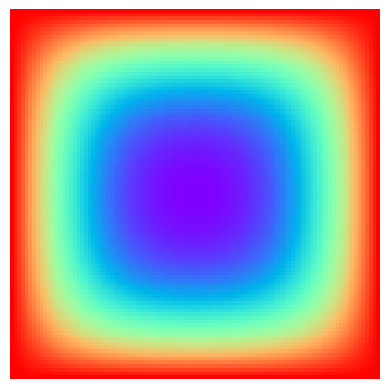

In [33]:
plot_grid(G5)